In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx

from pathlib import Path

In [3]:
from pathlib import Path

print("Current working directory:")
print(Path.cwd())

print("\nFiles in current directory:")
for p in Path.cwd().iterdir():
    print(p)

Current working directory:
c:\Users\ADMIN\FinGraph-Sentinel\notebooks

Files in current directory:
c:\Users\ADMIN\FinGraph-Sentinel\notebooks\.ipynb_checkpoints
c:\Users\ADMIN\FinGraph-Sentinel\notebooks\01_environment_test.ipynb.ipynb
c:\Users\ADMIN\FinGraph-Sentinel\notebooks\02_stock_data_exploration.ipynb
c:\Users\ADMIN\FinGraph-Sentinel\notebooks\06_financial_graph.ipynb


In [11]:
from pathlib import Path
import pandas as pd

# =========================================================
# 1. PROJECT PATHS
# =========================================================

PROJECT_ROOT = Path(r"C:\Users\ADMIN\FinGraph-Sentinel")

RAW_STOCK_PATH = PROJECT_ROOT / "data" / "raw" / "stock_prices"
PROCESSED_PATH = PROJECT_ROOT / "data" / "processed"

PROCESSED_PATH.mkdir(parents=True, exist_ok=True)

OUTPUT_FILE = PROCESSED_PATH / "stock_prices_clean.csv"


# =========================================================
# 2. FIND RAW STOCK FILES
# =========================================================

csv_files = sorted(RAW_STOCK_PATH.glob("*.csv"))

print(f"Found {len(csv_files)} stock files.")

if not csv_files:
    raise FileNotFoundError(
        f"No CSV files found in {RAW_STOCK_PATH}"
    )


# =========================================================
# 3. READ ALL STOCK FILES
# =========================================================

dataframes = []

for file in csv_files:

    print(f"Reading: {file.name}")

    temp_df = pd.read_csv(file)

    # Add ticker if it does not exist
    if "ticker" not in temp_df.columns:
        temp_df["ticker"] = file.stem.upper()

    dataframes.append(temp_df)


# =========================================================
# 4. COMBINE DATA
# =========================================================

df = pd.concat(
    dataframes,
    ignore_index=True
)

print("\nCombined shape:", df.shape)


# =========================================================
# 5. STANDARDIZE COLUMN NAMES
# =========================================================

df.columns = (
    df.columns
    .str.strip()
    .str.lower()
)

print("\nColumns:")
print(df.columns.tolist())


# =========================================================
# 6. FIX MIXED TIMEZONES
# =========================================================

print("\nConverting dates...")

df["date"] = pd.to_datetime(
    df["date"],
    errors="coerce",
    utc=True
)

# Remove timezone information
df["date"] = df["date"].dt.tz_localize(None)


# =========================================================
# 7. CONVERT NUMERIC COLUMNS
# =========================================================

numeric_columns = [
    "open",
    "high",
    "low",
    "close",
    "volume",
    "dividends",
    "stock splits"
]

for column in numeric_columns:

    if column in df.columns:

        df[column] = pd.to_numeric(
            df[column],
            errors="coerce"
        )


# =========================================================
# 8. CLEAN TICKER AND COMPANY
# =========================================================

df["ticker"] = (
    df["ticker"]
    .astype(str)
    .str.strip()
    .str.upper()
)

if "company" in df.columns:

    df["company"] = (
        df["company"]
        .astype(str)
        .str.strip()
    )


# =========================================================
# 9. REMOVE INVALID DATES
# =========================================================

before = len(df)

df = df.dropna(
    subset=["date"]
)

after = len(df)

print(
    f"Removed {before - after} rows "
    "with invalid dates."
)


# =========================================================
# 10. REMOVE DUPLICATES
# =========================================================

before = len(df)

df = df.drop_duplicates(
    subset=["ticker", "date"],
    keep="last"
)

after = len(df)

print(
    f"Removed {before - after} duplicate rows."
)


# =========================================================
# 11. SORT DATA
# =========================================================

df = df.sort_values(
    by=["ticker", "date"]
).reset_index(drop=True)


# =========================================================
# 12. HANDLE MISSING PRICE VALUES
# =========================================================

price_columns = [
    "open",
    "high",
    "low",
    "close"
]

for column in price_columns:

    df[column] = (
        df.groupby("ticker")[column]
        .transform(
            lambda x: x.ffill().bfill()
        )
    )


# =========================================================
# 13. REMOVE REMAINING INVALID PRICE ROWS
# =========================================================

df = df.dropna(
    subset=[
        "open",
        "high",
        "low",
        "close"
    ]
)


# =========================================================
# 14. FINAL SORT
# =========================================================

df = df.sort_values(
    by=["ticker", "date"]
).reset_index(drop=True)


# =========================================================
# 15. SAVE PROCESSED DATA
# =========================================================

df.to_csv(
    OUTPUT_FILE,
    index=False
)


# =========================================================
# 16. VALIDATION
# =========================================================

print("\n")
print("=" * 60)
print("DATA PROCESSING COMPLETE")
print("=" * 60)

print("\nOutput:")
print(OUTPUT_FILE)

print("\nFinal shape:")
print(df.shape)

print("\nCompanies:")
print(sorted(df["ticker"].unique()))

print("\nRows per company:")
print(df["ticker"].value_counts())

print("\nMissing values:")
print(df.isnull().sum())

print("\nDate range:")
print("Start:", df["date"].min())
print("End:  ", df["date"].max())

print("\nFirst 5 rows:")
display(df.head())

Found 10 stock files.
Reading: AAPL.csv
Reading: AMZN.csv
Reading: GOOGL.csv
Reading: JPM.csv
Reading: MA.csv
Reading: META.csv
Reading: MSFT.csv
Reading: NVDA.csv
Reading: TSLA.csv
Reading: V.csv

Combined shape: (12550, 10)

Columns:
['date', 'open', 'high', 'low', 'close', 'volume', 'dividends', 'stock splits', 'ticker', 'company']

Converting dates...
Removed 0 rows with invalid dates.
Removed 0 duplicate rows.


DATA PROCESSING COMPLETE

Output:
C:\Users\ADMIN\FinGraph-Sentinel\data\processed\stock_prices_clean.csv

Final shape:
(12550, 10)

Companies:
['AAPL', 'AMZN', 'GOOGL', 'JPM', 'MA', 'META', 'MSFT', 'NVDA', 'TSLA', 'V']

Rows per company:
ticker
AAPL     1255
AMZN     1255
GOOGL    1255
JPM      1255
MA       1255
META     1255
MSFT     1255
NVDA     1255
TSLA     1255
V        1255
Name: count, dtype: int64

Missing values:
date            0
open            0
high            0
low             0
close           0
volume          0
dividends       0
stock splits    0
ticker 

,date,open,high,low,close,volume,dividends,stock splits,ticker,company
0,2021-08-19 04:00:00,141.458092,144.354945,140.941146,143.086960,86960300,0.0,0.0,AAPL,Apple
1,2021-08-20 04:00:00,143.808694,144.842585,143.164946,144.540222,60549600,0.0,0.0,AAPL,Apple
2,2021-08-23 04:00:00,144.657268,146.490971,144.247614,146.022797,60131800,0.0,0.0,AAPL,Apple
3,2021-08-24 04:00:00,145.769202,147.144478,145.476587,145.935013,48606400,0.0,0.0,AAPL,Apple
4,2021-08-25 04:00:00,146.120355,146.617804,144.159864,144.706070,58991300,0.0,0.0,AAPL,Apple


In [12]:
from pathlib import Path

file = Path(r"C:\Users\ADMIN\FinGraph-Sentinel\data\processed\stock_prices_clean.csv")

print("Exists:", file.exists())

if file.exists():
    print("File size:", round(file.stat().st_size / 1024, 2), "KB")

Exists: True
File size: 1504.56 KB


In [13]:
from pathlib import Path
import pandas as pd

DATA_PATH = Path("../data/processed/stock_prices_clean.csv")

df = pd.read_csv(DATA_PATH)

df["date"] = pd.to_datetime(df["date"])

print("Shape:", df.shape)
display(df.head())

Shape: (12550, 10)


,date,open,high,low,close,volume,dividends,stock splits,ticker,company
0,2021-08-19 04:00:00,141.458092,144.354945,140.941146,143.086960,86960300,0.0,0.0,AAPL,Apple
1,2021-08-20 04:00:00,143.808694,144.842585,143.164946,144.540222,60549600,0.0,0.0,AAPL,Apple
2,2021-08-23 04:00:00,144.657268,146.490971,144.247614,146.022797,60131800,0.0,0.0,AAPL,Apple
3,2021-08-24 04:00:00,145.769202,147.144478,145.476587,145.935013,48606400,0.0,0.0,AAPL,Apple
4,2021-08-25 04:00:00,146.120355,146.617804,144.159864,144.706070,58991300,0.0,0.0,AAPL,Apple


In [14]:
df.shape

(12550, 10)

In [15]:
df.columns

Index(['date', 'open', 'high', 'low', 'close', 'volume', 'dividends',
       'stock splits', 'ticker', 'company'],
      dtype='str')

In [16]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 12550 entries, 0 to 12549
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   date          12550 non-null  datetime64[us]
 1   open          12550 non-null  float64       
 2   high          12550 non-null  float64       
 3   low           12550 non-null  float64       
 4   close         12550 non-null  float64       
 5   volume        12550 non-null  int64         
 6   dividends     12550 non-null  float64       
 7   stock splits  12550 non-null  float64       
 8   ticker        12550 non-null  str           
 9   company       12550 non-null  str           
dtypes: datetime64[us](1), float64(6), int64(1), str(2)
memory usage: 980.6 KB


In [18]:
df["date"].head(10)

0   2021-08-19 04:00:00
1   2021-08-20 04:00:00
2   2021-08-23 04:00:00
3   2021-08-24 04:00:00
4   2021-08-25 04:00:00
5   2021-08-26 04:00:00
6   2021-08-27 04:00:00
7   2021-08-30 04:00:00
8   2021-08-31 04:00:00
9   2021-09-01 04:00:00
Name: date, dtype: datetime64[us]

In [19]:
df["date"].dtype

dtype('<M8[us]')

In [20]:
df["date"] = pd.to_datetime(df["date"], errors="coerce")

In [21]:
df["date"].isna().sum()

np.int64(0)

In [24]:
price_df = df.pivot(
    index="date",
    columns="ticker",
    values="close"
)

In [25]:
price_df.head()

ticker,AAPL,AMZN,GOOGL,JPM,MA,META,MSFT,NVDA,TSLA,V
date,,,,,,,,,,
2021-08-19 04:00:00,143.086960,159.387497,134.487473,136.137665,346.896545,352.028656,285.354431,19.729757,224.490005,222.961411
2021-08-20 04:00:00,144.540222,159.997498,136.221573,136.525925,344.644073,356.241638,292.652527,20.744246,226.753326,222.759201
2021-08-23 04:00:00,146.022797,163.293503,138.810638,138.273071,350.488556,360.186981,292.931274,21.882309,235.433334,225.435852
2021-08-24 04:00:00,145.935013,165.289001,140.019913,139.129028,351.236145,362.328217,290.979431,21.717882,236.163330,225.532120
2021-08-25 04:00:00,144.706070,164.959000,140.830231,141.996841,348.634369,365.183105,290.392853,22.136435,237.066666,223.943466


In [26]:
price_df.isna().sum()

ticker
AAPL     0
AMZN     0
GOOGL    0
JPM      0
MA       0
META     0
MSFT     0
NVDA     0
TSLA     0
V        0
dtype: int64

In [27]:
price_df = price_df.ffill()
price_df = price_df.dropna()

In [28]:
price_df.shape

(1255, 10)

In [29]:
returns = price_df.pct_change()

In [30]:
returns = returns.dropna()

In [31]:
returns.head()

ticker,AAPL,AMZN,GOOGL,JPM,MA,META,MSFT,NVDA,TSLA,V
date,,,,,,,,,,
2021-08-20 04:00:00,0.010156,0.003827,0.012894,0.002852,-0.006493,0.011968,0.025576,0.051419,0.010082,-0.000907
2021-08-23 04:00:00,0.010257,0.020600,0.019006,0.012797,0.016958,0.011075,0.000952,0.054862,0.038280,0.012016
2021-08-24 04:00:00,-0.000601,0.012220,0.008712,0.006190,0.002133,0.005945,-0.006663,-0.007514,0.003101,0.000427
2021-08-25 04:00:00,-0.008421,-0.001997,0.005787,0.020613,-0.007407,0.007879,-0.002016,0.019272,0.003825,-0.007044
2021-08-26 04:00:00,-0.005528,0.005098,-0.004494,0.005158,-0.017377,-0.010885,-0.009669,-0.006528,-0.014117,-0.008900


In [32]:
correlation_matrix = returns.corr()

In [33]:
correlation_matrix

ticker,AAPL,AMZN,GOOGL,JPM,MA,META,MSFT,NVDA,TSLA,V
ticker,,,,,,,,,,
AAPL,1.000000,0.493822,0.517332,0.359589,0.483266,0.446402,0.531562,0.477481,0.467205,0.465803
AMZN,0.493822,1.000000,0.620722,0.351348,0.419459,0.587168,0.610041,0.529928,0.441086,0.381786
GOOGL,0.517332,0.620722,1.000000,0.317552,0.372011,0.533398,0.547861,0.500806,0.416744,0.346192
JPM,0.359589,0.351348,0.317552,1.000000,0.477558,0.297858,0.296517,0.327722,0.319858,0.477821
MA,0.483266,0.419459,0.372011,0.477558,1.000000,0.394143,0.455410,0.351428,0.283375,0.881086
META,0.446402,0.587168,0.533398,0.297858,0.394143,1.000000,0.510159,0.484114,0.350974,0.346475
MSFT,0.531562,0.610041,0.547861,0.296517,0.455410,0.510159,1.000000,0.565413,0.384953,0.402555
NVDA,0.477481,0.529928,0.500806,0.327722,0.351428,0.484114,0.565413,1.000000,0.463387,0.322008
TSLA,0.467205,0.441086,0.416744,0.319858,0.283375,0.350974,0.384953,0.463387,1.000000,0.293520


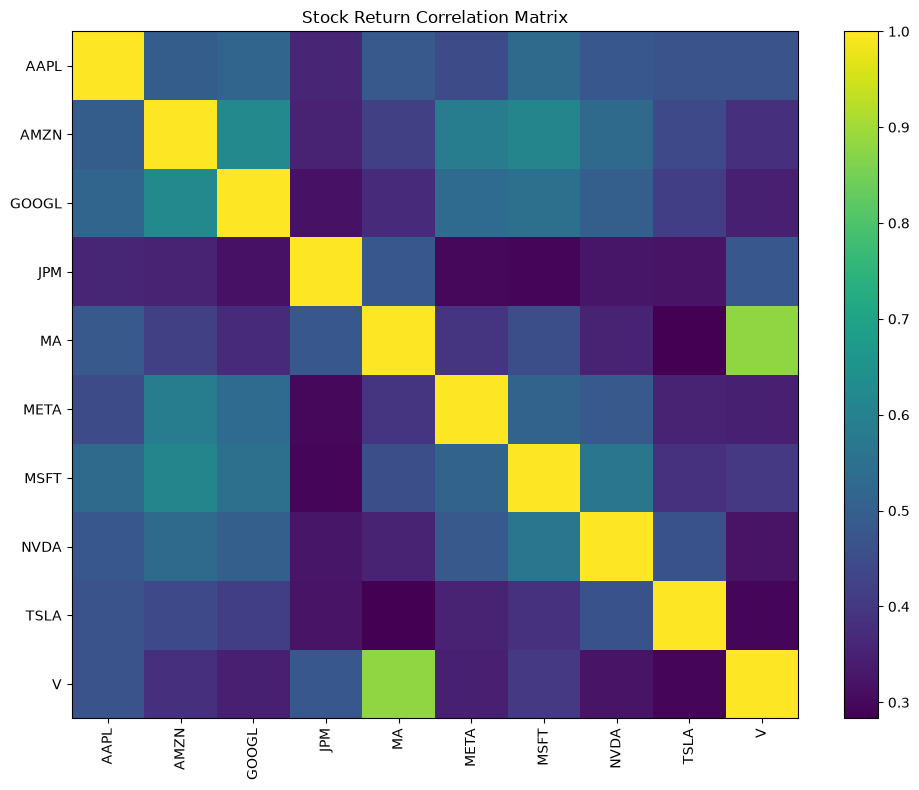

In [34]:
plt.figure(figsize=(10, 8))

plt.imshow(correlation_matrix, aspect="auto")
plt.colorbar()

plt.xticks(
    range(len(correlation_matrix.columns)),
    correlation_matrix.columns,
    rotation=90
)

plt.yticks(
    range(len(correlation_matrix.columns)),
    correlation_matrix.columns
)

plt.title("Stock Return Correlation Matrix")
plt.tight_layout()

plt.show()

In [35]:
CORRELATION_THRESHOLD = 0.60

In [36]:
G = nx.Graph()

In [37]:
for ticker in correlation_matrix.columns:
    G.add_node(ticker)

In [38]:
G.number_of_nodes()

10

In [39]:
for i in correlation_matrix.columns:
    for j in correlation_matrix.columns:
        
        if i != j:
            correlation = correlation_matrix.loc[i, j]
            
            if abs(correlation) >= CORRELATION_THRESHOLD:
                G.add_edge(
                    i,
                    j,
                    weight=correlation
                )

In [40]:
G = nx.Graph()

tickers = correlation_matrix.columns

for ticker in tickers:
    G.add_node(ticker)

for i in range(len(tickers)):
    for j in range(i + 1, len(tickers)):
        
        ticker_a = tickers[i]
        ticker_b = tickers[j]
        
        correlation = correlation_matrix.loc[
            ticker_a,
            ticker_b
        ]
        
        if abs(correlation) >= CORRELATION_THRESHOLD:
            G.add_edge(
                ticker_a,
                ticker_b,
                weight=correlation
            )

In [41]:
print("Nodes:", G.number_of_nodes())
print("Edges:", G.number_of_edges())

Nodes: 10
Edges: 3


In [42]:
print(list(G.nodes()))

['AAPL', 'AMZN', 'GOOGL', 'JPM', 'MA', 'META', 'MSFT', 'NVDA', 'TSLA', 'V']


In [43]:
print(list(G.edges(data=True)))

[('AMZN', 'GOOGL', {'weight': np.float64(0.6207220165177152)}), ('AMZN', 'MSFT', {'weight': np.float64(0.6100405413245391)}), ('MA', 'V', {'weight': np.float64(0.8810862842646711)})]


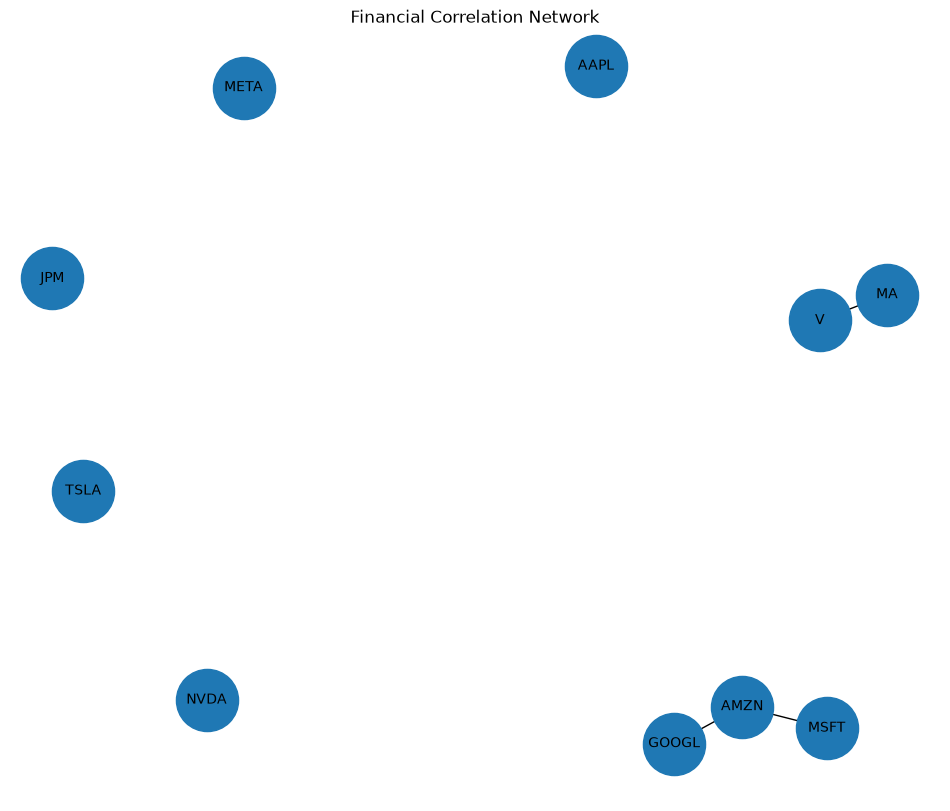

In [44]:
plt.figure(figsize=(12, 10))

pos = nx.spring_layout(
    G,
    seed=42
)

nx.draw_networkx(
    G,
    pos,
    with_labels=True,
    node_size=2000,
    font_size=10
)

plt.title(
    "Financial Correlation Network"
)

plt.axis("off")
plt.show()

In [45]:
edge_weights = [
    abs(G[u][v]["weight"]) * 5
    for u, v in G.edges()
]

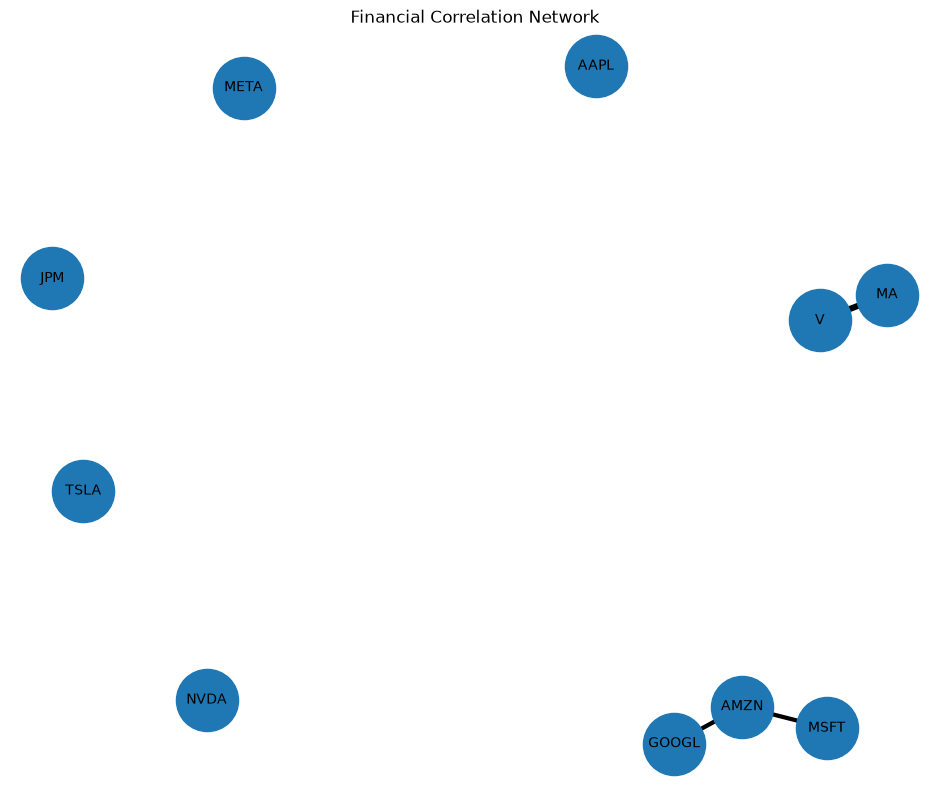

In [46]:
plt.figure(figsize=(12, 10))

pos = nx.spring_layout(
    G,
    seed=42
)

nx.draw_networkx_nodes(
    G,
    pos,
    node_size=2000
)

nx.draw_networkx_labels(
    G,
    pos,
    font_size=10
)

nx.draw_networkx_edges(
    G,
    pos,
    width=edge_weights
)

plt.title(
    "Financial Correlation Network"
)

plt.axis("off")
plt.show()

In [ ]:
degree = dict(G.degree())

In [49]:
degree

{'AAPL': 0,
 'AMZN': 2,
 'GOOGL': 1,
 'JPM': 0,
 'MA': 1,
 'META': 0,
 'MSFT': 1,
 'NVDA': 0,
 'TSLA': 0,
 'V': 1}

In [50]:
degree_df = pd.DataFrame(
    degree.items(),
    columns=["Ticker", "Degree"]
)

degree_df = degree_df.sort_values(
    "Degree",
    ascending=False
)

degree_df

,Ticker,Degree
1,AMZN,2
2,GOOGL,1
9,V,1
4,MA,1
6,MSFT,1
0,AAPL,0
5,META,0
3,JPM,0
7,NVDA,0
8,TSLA,0


In [51]:
weighted_degree = dict(
    G.degree(weight="weight")
)

In [52]:
weighted_degree_df = pd.DataFrame(
    weighted_degree.items(),
    columns=["Ticker", "Weighted_Degree"]
)

weighted_degree_df = weighted_degree_df.sort_values(
    "Weighted_Degree",
    ascending=False
)

weighted_degree_df

,Ticker,Weighted_Degree
1,AMZN,1.230763
4,MA,0.881086
9,V,0.881086
2,GOOGL,0.620722
6,MSFT,0.610041
0,AAPL,0.000000
5,META,0.000000
3,JPM,0.000000
7,NVDA,0.000000
8,TSLA,0.000000


In [53]:
degree_centrality = nx.degree_centrality(G)

In [54]:
centrality_df = pd.DataFrame(
    degree_centrality.items(),
    columns=["Ticker", "Degree_Centrality"]
)

centrality_df = centrality_df.sort_values(
    "Degree_Centrality",
    ascending=False
)

centrality_df

,Ticker,Degree_Centrality
1,AMZN,0.222222
2,GOOGL,0.111111
9,V,0.111111
4,MA,0.111111
6,MSFT,0.111111
0,AAPL,0.000000
5,META,0.000000
3,JPM,0.000000
7,NVDA,0.000000
8,TSLA,0.000000


In [55]:
betweenness = nx.betweenness_centrality(G)

In [56]:
betweenness_df = pd.DataFrame(
    betweenness.items(),
    columns=["Ticker", "Betweenness_Centrality"]
)

betweenness_df = betweenness_df.sort_values(
    "Betweenness_Centrality",
    ascending=False
)

betweenness_df

,Ticker,Betweenness_Centrality
1,AMZN,0.027778
0,AAPL,0.000000
2,GOOGL,0.000000
3,JPM,0.000000
4,MA,0.000000
5,META,0.000000
6,MSFT,0.000000
7,NVDA,0.000000
8,TSLA,0.000000
9,V,0.000000


In [57]:
pagerank = nx.pagerank(
    G,
    weight="weight"
)

In [58]:
pagerank_df = pd.DataFrame(
    pagerank.items(),
    columns=["Ticker", "PageRank"]
)

pagerank_df = pagerank_df.sort_values(
    "PageRank",
    ascending=False
)

pagerank_df

,Ticker,PageRank
1,AMZN,0.253821
4,MA,0.173913
9,V,0.173913
2,GOOGL,0.134895
6,MSFT,0.133023
0,AAPL,0.026087
5,META,0.026087
3,JPM,0.026087
7,NVDA,0.026087
8,TSLA,0.026087


In [60]:
graph_metrics = pd.DataFrame({
    "Ticker": list(G.nodes()),
    "Degree": [
        G.degree(node)
        for node in G.nodes()
    ],
    "Weighted_Degree": [
        G.degree(node, weight="weight")
        for node in G.nodes()
    ],
    "Degree_Centrality": [
        degree_centrality[node]
        for node in G.nodes()
    ],
    "Betweenness_Centrality": [
        betweenness[node]
        for node in G.nodes()
    ],
    "PageRank": [
        pagerank[node]
        for node in G.nodes()
    ]
})

In [61]:
graph_metrics.sort_values(
    "PageRank",
    ascending=False
)

,Ticker,Degree,Weighted_Degree,Degree_Centrality,Betweenness_Centrality,PageRank
1,AMZN,2,1.230763,0.222222,0.027778,0.253821
4,MA,1,0.881086,0.111111,0.000000,0.173913
9,V,1,0.881086,0.111111,0.000000,0.173913
2,GOOGL,1,0.620722,0.111111,0.000000,0.134895
6,MSFT,1,0.610041,0.111111,0.000000,0.133023
0,AAPL,0,0.000000,0.000000,0.000000,0.026087
5,META,0,0.000000,0.000000,0.000000,0.026087
3,JPM,0,0.000000,0.000000,0.000000,0.026087
7,NVDA,0,0.000000,0.000000,0.000000,0.026087
8,TSLA,0,0.000000,0.000000,0.000000,0.026087


In [62]:
cumulative_returns = (
    (1 + returns).prod() - 1
)

In [63]:
performance_df = pd.DataFrame(
    cumulative_returns,
    columns=["Cumulative_Return"]
)

performance_df.index.name = "Ticker"

performance_df

,Cumulative_Return
Ticker,
AAPL,1.209321
AMZN,0.660231
GOOGL,1.571132
JPM,1.624696
MA,0.661187
META,0.566321
MSFT,0.704967
NVDA,10.113162
TSLA,0.546929


In [64]:
performance_df = performance_df.reset_index()

In [65]:
volatility = returns.std()

In [66]:
volatility_df = pd.DataFrame(
    volatility,
    columns=["Volatility"]
)

volatility_df.index.name = "Ticker"

volatility_df = volatility_df.reset_index()

In [67]:
final_graph_metrics = (
    graph_metrics
    .merge(
        performance_df,
        on="Ticker",
        how="left"
    )
    .merge(
        volatility_df,
        on="Ticker",
        how="left"
    )
)

In [68]:
final_graph_metrics

,Ticker,Degree,Weighted_Degree,Degree_Centrality,Betweenness_Centrality,PageRank,Cumulative_Return,Volatility
0,AAPL,0,0.000000,0.000000,0.000000,0.026087,1.209321,0.017664
1,AMZN,2,1.230763,0.222222,0.027778,0.253821,0.660231,0.022923
2,GOOGL,1,0.620722,0.111111,0.000000,0.134895,1.571132,0.020229
3,JPM,0,0.000000,0.000000,0.000000,0.026087,1.624696,0.015383
4,MA,1,0.881086,0.111111,0.000000,0.173913,0.661187,0.015108
5,META,0,0.000000,0.000000,0.000000,0.026087,0.566321,0.028266
6,MSFT,1,0.610041,0.111111,0.000000,0.133023,0.704967,0.017737
7,NVDA,0,0.000000,0.000000,0.000000,0.026087,10.113162,0.032695
8,TSLA,0,0.000000,0.000000,0.000000,0.026087,0.546929,0.037575
9,V,1,0.881086,0.111111,0.000000,0.173913,0.655757,0.014442


In [69]:
final_graph_metrics["Network_Score"] = (
    final_graph_metrics["Degree_Centrality"] * 0.30
    +
    final_graph_metrics["Betweenness_Centrality"] * 0.20
    +
    final_graph_metrics["PageRank"] * 0.30
    +
    final_graph_metrics["Cumulative_Return"] * 0.20
)

In [70]:
final_graph_metrics = final_graph_metrics.sort_values(
    "Network_Score",
    ascending=False
)

In [71]:
final_graph_metrics

,Ticker,Degree,Weighted_Degree,Degree_Centrality,Betweenness_Centrality,PageRank,Cumulative_Return,Volatility,Network_Score
7,NVDA,0,0.000000,0.000000,0.000000,0.026087,10.113162,0.032695,2.030459
2,GOOGL,1,0.620722,0.111111,0.000000,0.134895,1.571132,0.020229,0.388028
3,JPM,0,0.000000,0.000000,0.000000,0.026087,1.624696,0.015383,0.332765
1,AMZN,2,1.230763,0.222222,0.027778,0.253821,0.660231,0.022923,0.280415
0,AAPL,0,0.000000,0.000000,0.000000,0.026087,1.209321,0.017664,0.249690
4,MA,1,0.881086,0.111111,0.000000,0.173913,0.661187,0.015108,0.217745
9,V,1,0.881086,0.111111,0.000000,0.173913,0.655757,0.014442,0.216659
6,MSFT,1,0.610041,0.111111,0.000000,0.133023,0.704967,0.017737,0.214234
5,META,0,0.000000,0.000000,0.000000,0.026087,0.566321,0.028266,0.121090
8,TSLA,0,0.000000,0.000000,0.000000,0.026087,0.546929,0.037575,0.117212


In [72]:
final_graph_metrics.head(10)

,Ticker,Degree,Weighted_Degree,Degree_Centrality,Betweenness_Centrality,PageRank,Cumulative_Return,Volatility,Network_Score
7,NVDA,0,0.000000,0.000000,0.000000,0.026087,10.113162,0.032695,2.030459
2,GOOGL,1,0.620722,0.111111,0.000000,0.134895,1.571132,0.020229,0.388028
3,JPM,0,0.000000,0.000000,0.000000,0.026087,1.624696,0.015383,0.332765
1,AMZN,2,1.230763,0.222222,0.027778,0.253821,0.660231,0.022923,0.280415
0,AAPL,0,0.000000,0.000000,0.000000,0.026087,1.209321,0.017664,0.249690
4,MA,1,0.881086,0.111111,0.000000,0.173913,0.661187,0.015108,0.217745
9,V,1,0.881086,0.111111,0.000000,0.173913,0.655757,0.014442,0.216659
6,MSFT,1,0.610041,0.111111,0.000000,0.133023,0.704967,0.017737,0.214234
5,META,0,0.000000,0.000000,0.000000,0.026087,0.566321,0.028266,0.121090
8,TSLA,0,0.000000,0.000000,0.000000,0.026087,0.546929,0.037575,0.117212


In [73]:
from networkx.algorithms.community import greedy_modularity_communities

In [74]:
communities = greedy_modularity_communities(G)

In [75]:
for i, community in enumerate(communities):
    print(f"Community {i + 1}:")
    print(list(community))

Community 1:
['AMZN', 'GOOGL', 'MSFT']
Community 2:
['V', 'MA']
Community 3:
['AAPL']
Community 4:
['JPM']
Community 5:
['META']
Community 6:
['NVDA']
Community 7:
['TSLA']


In [76]:
community_sizes = [
    len(community)
    for community in communities
]

community_sizes

[3, 2, 1, 1, 1, 1, 1]

In [77]:
for i, community in enumerate(communities):
    print(
        f"Community {i + 1}: "
        f"{len(community)} companies"
    )

Community 1: 3 companies
Community 2: 2 companies
Community 3: 1 companies
Community 4: 1 companies
Community 5: 1 companies
Community 6: 1 companies
Community 7: 1 companies


In [78]:
output_path = Path(
    "../data/processed/graph_metrics.csv"
)

final_graph_metrics.to_csv(
    output_path,
    index=False
)

In [79]:
output_path

WindowsPath('../data/processed/graph_metrics.csv')

In [80]:
correlation_matrix.to_csv(
    "../data/processed/correlation_matrix.csv"
)

In [81]:
nx.write_gml(
    G,
    "../data/processed/financial_graph.gml"
)

In [82]:
print("Dataset shape:", price_df.shape)

print(
    "Number of companies:",
    len(correlation_matrix.columns)
)

print(
    "Graph nodes:",
    G.number_of_nodes()
)

print(
    "Graph edges:",
    G.number_of_edges()
)

print(
    "Number of communities:",
    len(communities)
)

print("\nTop companies:")
print(
    final_graph_metrics.head(10)
)

Dataset shape: (1255, 10)
Number of companies: 10
Graph nodes: 10
Graph edges: 3
Number of communities: 7

Top companies:
  Ticker  Degree  Weighted_Degree  Degree_Centrality  Betweenness_Centrality  \
7   NVDA       0         0.000000           0.000000                0.000000   
2  GOOGL       1         0.620722           0.111111                0.000000   
3    JPM       0         0.000000           0.000000                0.000000   
1   AMZN       2         1.230763           0.222222                0.027778   
0   AAPL       0         0.000000           0.000000                0.000000   
4     MA       1         0.881086           0.111111                0.000000   
9      V       1         0.881086           0.111111                0.000000   
6   MSFT       1         0.610041           0.111111                0.000000   
5   META       0         0.000000           0.000000                0.000000   
8   TSLA       0         0.000000           0.000000                0.000000  

In [89]:
import sys
from pathlib import Path

SRC_PATH = Path("../src").resolve()

if str(SRC_PATH) not in sys.path:
    sys.path.insert(0, str(SRC_PATH))

print("SRC:", SRC_PATH)
print("File exists:", (SRC_PATH / "graph" / "financial_graph.py").exists())

SRC: C:\Users\ADMIN\FinGraph-Sentinel\src
File exists: True


In [90]:
from graph.financial_graph import build_financial_graph_pipeline

In [91]:
import sys
from pathlib import Path

SRC_PATH = Path("../src").resolve()

if str(SRC_PATH) not in sys.path:
    sys.path.insert(0, str(SRC_PATH))

from graph.financial_graph import build_financial_graph_pipeline

print("Financial graph module imported successfully!")

Financial graph module imported successfully!


In [92]:
from pathlib import Path

processed_path = Path("../data/processed")

print("Processed directory:", processed_path.resolve())

print("\nFiles:")
for file in processed_path.iterdir():
    print(file.name)

Processed directory: C:\Users\ADMIN\FinGraph-Sentinel\data\processed

Files:
correlation_matrix.csv
financial_graph.gml
graph_metrics.csv
stock_prices_clean.csv


In [93]:
import pandas as pd

graph_metrics_path = Path("../data/processed/graph_metrics.csv")

graph_metrics = pd.read_csv(graph_metrics_path)

graph_metrics.head()

,Ticker,Degree,Weighted_Degree,Degree_Centrality,Betweenness_Centrality,PageRank,Cumulative_Return,Volatility,Network_Score
0,NVDA,0,0.000000,0.000000,0.000000,0.026087,10.113162,0.032695,2.030459
1,GOOGL,1,0.620722,0.111111,0.000000,0.134895,1.571132,0.020229,0.388028
2,JPM,0,0.000000,0.000000,0.000000,0.026087,1.624696,0.015383,0.332765
3,AMZN,2,1.230763,0.222222,0.027778,0.253821,0.660231,0.022923,0.280415
4,AAPL,0,0.000000,0.000000,0.000000,0.026087,1.209321,0.017664,0.249690


In [94]:
print("Shape:", graph_metrics.shape)
print("\nColumns:")
print(graph_metrics.columns.tolist())

Shape: (10, 9)

Columns:
['Ticker', 'Degree', 'Weighted_Degree', 'Degree_Centrality', 'Betweenness_Centrality', 'PageRank', 'Cumulative_Return', 'Volatility', 'Network_Score']


In [95]:
graph_metrics.info()

<class 'pandas.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 9 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Ticker                  10 non-null     str    
 1   Degree                  10 non-null     int64  
 2   Weighted_Degree         10 non-null     float64
 3   Degree_Centrality       10 non-null     float64
 4   Betweenness_Centrality  10 non-null     float64
 5   PageRank                10 non-null     float64
 6   Cumulative_Return       10 non-null     float64
 7   Volatility              10 non-null     float64
 8   Network_Score           10 non-null     float64
dtypes: float64(7), int64(1), str(1)
memory usage: 848.0 bytes


In [96]:
graph_metrics.describe()

,Degree,Weighted_Degree,Degree_Centrality,Betweenness_Centrality,PageRank,Cumulative_Return,Volatility,Network_Score
count,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000
mean,0.600000,0.422370,0.066667,0.002778,0.100000,1.831370,0.022202,0.416830
std,0.699206,0.476199,0.077690,0.008784,0.084466,2.938770,0.008064,0.573122
min,0.000000,0.000000,0.000000,0.000000,0.026087,0.546929,0.014442,0.117212
25%,0.000000,0.000000,0.000000,0.000000,0.026087,0.656876,0.015953,0.214840
50%,0.500000,0.305020,0.055556,0.000000,0.079555,0.683077,0.018983,0.233717
75%,1.000000,0.815995,0.111111,0.000000,0.164159,1.480679,0.026930,0.319678
max,2.000000,1.230763,0.222222,0.027778,0.253821,10.113162,0.037575,2.030459


In [97]:
graph_metrics.isnull().sum()

Ticker                    0
Degree                    0
Weighted_Degree           0
Degree_Centrality         0
Betweenness_Centrality    0
PageRank                  0
Cumulative_Return         0
Volatility                0
Network_Score             0
dtype: int64

In [98]:
stock_path = Path("../data/processed/stock_prices_clean.csv")

stock_df = pd.read_csv(stock_path)

stock_df.head()

,date,open,high,low,close,volume,dividends,stock splits,ticker,company
0,2021-08-19 04:00:00,141.458092,144.354945,140.941146,143.086960,86960300,0.0,0.0,AAPL,Apple
1,2021-08-20 04:00:00,143.808694,144.842585,143.164946,144.540222,60549600,0.0,0.0,AAPL,Apple
2,2021-08-23 04:00:00,144.657268,146.490971,144.247614,146.022797,60131800,0.0,0.0,AAPL,Apple
3,2021-08-24 04:00:00,145.769202,147.144478,145.476587,145.935013,48606400,0.0,0.0,AAPL,Apple
4,2021-08-25 04:00:00,146.120355,146.617804,144.159864,144.706070,58991300,0.0,0.0,AAPL,Apple


In [100]:
print(stock_df.shape)
print(stock_df.columns.tolist())

(12550, 10)
['date', 'open', 'high', 'low', 'close', 'volume', 'dividends', 'stock splits', 'ticker', 'company']


In [102]:
stock_df["ticker"].unique()

<StringArray>
['AAPL', 'AMZN', 'GOOGL', 'JPM', 'MA', 'META', 'MSFT', 'NVDA', 'TSLA', 'V']
Length: 10, dtype: str

In [103]:
stock_df["date"] = pd.to_datetime(stock_df["date"])

In [107]:
stock_df = stock_df.sort_values(["ticker", "date"])

stock_df["Return"] = (
    stock_df
    .groupby("ticker")["close"]
    .pct_change()
)

In [108]:
stock_df.head()

,date,open,high,low,close,volume,dividends,stock splits,ticker,company,Return
0,2021-08-19 04:00:00,141.458092,144.354945,140.941146,143.086960,86960300,0.0,0.0,AAPL,Apple,NaN
1,2021-08-20 04:00:00,143.808694,144.842585,143.164946,144.540222,60549600,0.0,0.0,AAPL,Apple,0.010156
2,2021-08-23 04:00:00,144.657268,146.490971,144.247614,146.022797,60131800,0.0,0.0,AAPL,Apple,0.010257
3,2021-08-24 04:00:00,145.769202,147.144478,145.476587,145.935013,48606400,0.0,0.0,AAPL,Apple,-0.000601
4,2021-08-25 04:00:00,146.120355,146.617804,144.159864,144.706070,58991300,0.0,0.0,AAPL,Apple,-0.008421


In [109]:
stock_df = stock_df.dropna(subset=["Return"])

In [110]:
print("Shape after removing NaN returns:", stock_df.shape)

Shape after removing NaN returns: (12540, 11)


In [112]:
volatility = (
    stock_df
    .groupby("ticker")["Return"]
    .std()
    .reset_index()
)

volatility.columns = [
    "Ticker",
    "Volatility"
]

volatility.head()

,Ticker,Volatility
0,AAPL,0.017664
1,AMZN,0.022923
2,GOOGL,0.020229
3,JPM,0.015383
4,MA,0.015108


In [114]:
average_return = (
    stock_df
    .groupby("ticker")["Return"]
    .mean()
    .reset_index()
)

average_return.columns = [
    "ticker",
    "Average_Return"
]

In [115]:
average_return.head()

,ticker,Average_Return
0,AAPL,0.000788
1,AMZN,0.000666
2,GOOGL,0.000957
3,JPM,0.000888
4,MA,0.000519


In [116]:
def calculate_max_drawdown(prices):
    running_max = prices.cummax()
    drawdown = (prices - running_max) / running_max
    return drawdown.min()

In [118]:
drawdown = (
    stock_df
    .groupby("ticker")["close"]
    .apply(calculate_max_drawdown)
    .reset_index()
)

drawdown.columns = [
    "ticker",
    "Max_Drawdown"
]

In [119]:
drawdown.head()

,ticker,Max_Drawdown
0,AAPL,-0.333605
1,AMZN,-0.557258
2,GOOGL,-0.443201
3,JPM,-0.387716
4,MA,-0.282503


In [122]:
print("Volatility columns:")
print(volatility.columns.tolist())

print("\nAverage return columns:")
print(average_return.columns.tolist())

Volatility columns:
['Ticker', 'Volatility']

Average return columns:
['ticker', 'Average_Return']


In [123]:
volatility = volatility.rename(columns={"Ticker": "ticker"})
average_return = average_return.rename(columns={"Ticker": "ticker"})

In [124]:
financial_metrics = volatility.merge(
    average_return,
    on="ticker",
    how="left"
)
financial_metrics.head()

,ticker,Volatility,Average_Return
0,AAPL,0.017664,0.000788
1,AMZN,0.022923,0.000666
2,GOOGL,0.020229,0.000957
3,JPM,0.015383,0.000888
4,MA,0.015108,0.000519


In [125]:
financial_metrics

,ticker,Volatility,Average_Return
0,AAPL,0.017664,0.000788
1,AMZN,0.022923,0.000666
2,GOOGL,0.020229,0.000957
3,JPM,0.015383,0.000888
4,MA,0.015108,0.000519
5,META,0.028266,0.000761
6,MSFT,0.017737,0.000582
7,NVDA,0.032695,0.002451
8,TSLA,0.037575,0.001051
9,V,0.014442,0.000506


In [128]:
print("graph_metrics columns:")
print(graph_metrics.columns.tolist())

print("\nfinancial_metrics columns:")
print(financial_metrics.columns.tolist())

graph_metrics columns:
['Ticker', 'Degree', 'Weighted_Degree', 'Degree_Centrality', 'Betweenness_Centrality', 'PageRank', 'Cumulative_Return', 'Volatility', 'Network_Score']

financial_metrics columns:
['ticker', 'Volatility', 'Average_Return']


In [129]:
graph_metrics = graph_metrics.rename(columns={"Ticker": "ticker"})
financial_metrics = financial_metrics.rename(columns={"Ticker": "ticker"})

In [130]:
company_analysis = graph_metrics.merge(
    financial_metrics,
    on="ticker",
    how="left"
)

print("Company analysis shape:", company_analysis.shape)
display(company_analysis.head())

Company analysis shape: (10, 11)


,ticker,Degree,Weighted_Degree,Degree_Centrality,Betweenness_Centrality,PageRank,Cumulative_Return,Volatility_x,Network_Score,Volatility_y,Average_Return
0,NVDA,0,0.000000,0.000000,0.000000,0.026087,10.113162,0.032695,2.030459,0.032695,0.002451
1,GOOGL,1,0.620722,0.111111,0.000000,0.134895,1.571132,0.020229,0.388028,0.020229,0.000957
2,JPM,0,0.000000,0.000000,0.000000,0.026087,1.624696,0.015383,0.332765,0.015383,0.000888
3,AMZN,2,1.230763,0.222222,0.027778,0.253821,0.660231,0.022923,0.280415,0.022923,0.000666
4,AAPL,0,0.000000,0.000000,0.000000,0.026087,1.209321,0.017664,0.249690,0.017664,0.000788


In [132]:
company_analysis = graph_metrics.merge(
    financial_metrics,
    on="ticker",
    how="left"
)

In [133]:
company_analysis.head()

,ticker,Degree,Weighted_Degree,Degree_Centrality,Betweenness_Centrality,PageRank,Cumulative_Return,Volatility_x,Network_Score,Volatility_y,Average_Return
0,NVDA,0,0.000000,0.000000,0.000000,0.026087,10.113162,0.032695,2.030459,0.032695,0.002451
1,GOOGL,1,0.620722,0.111111,0.000000,0.134895,1.571132,0.020229,0.388028,0.020229,0.000957
2,JPM,0,0.000000,0.000000,0.000000,0.026087,1.624696,0.015383,0.332765,0.015383,0.000888
3,AMZN,2,1.230763,0.222222,0.027778,0.253821,0.660231,0.022923,0.280415,0.022923,0.000666
4,AAPL,0,0.000000,0.000000,0.000000,0.026087,1.209321,0.017664,0.249690,0.017664,0.000788


In [134]:
print("Shape:", company_analysis.shape)

Shape: (10, 11)


In [135]:
company_analysis.isnull().sum()

ticker                    0
Degree                    0
Weighted_Degree           0
Degree_Centrality         0
Betweenness_Centrality    0
PageRank                  0
Cumulative_Return         0
Volatility_x              0
Network_Score             0
Volatility_y              0
Average_Return            0
dtype: int64

In [136]:
from sklearn.preprocessing import MinMaxScaler

In [137]:
risk_columns = [
    "Volatility",
    "Max_Drawdown",
    "Degree_Centrality",
    "Betweenness_Centrality"
]

In [138]:
[c for c in risk_columns if c in company_analysis.columns]

['Degree_Centrality', 'Betweenness_Centrality']

In [141]:
print(company_analysis.columns.tolist())

['ticker', 'Degree', 'Weighted_Degree', 'Degree_Centrality', 'Betweenness_Centrality', 'PageRank', 'Cumulative_Return', 'Volatility_x', 'Network_Score', 'Volatility_y', 'Average_Return']


In [144]:
display(company_analysis.head())

,ticker,Degree,Weighted_Degree,Degree_Centrality,Betweenness_Centrality,PageRank,Cumulative_Return,Volatility,Network_Score,Average_Return
0,NVDA,0,0.000000,0.000000,0.000000,0.026087,10.113162,0.032695,2.030459,0.002451
1,GOOGL,1,0.620722,0.111111,0.000000,0.134895,1.571132,0.020229,0.388028,0.000957
2,JPM,0,0.000000,0.000000,0.000000,0.026087,1.624696,0.015383,0.332765,0.000888
3,AMZN,2,1.230763,0.222222,0.027778,0.253821,0.660231,0.022923,0.280415,0.000666
4,AAPL,0,0.000000,0.000000,0.000000,0.026087,1.209321,0.017664,0.249690,0.000788


In [143]:
# Remove the duplicate volatility column
company_analysis = company_analysis.drop(columns=["Volatility_y"])

# Rename Volatility_x to Volatility
company_analysis = company_analysis.rename(
    columns={"Volatility_x": "Volatility"}
)

print(company_analysis.columns.tolist())

['ticker', 'Degree', 'Weighted_Degree', 'Degree_Centrality', 'Betweenness_Centrality', 'PageRank', 'Cumulative_Return', 'Volatility', 'Network_Score', 'Average_Return']


In [145]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

company_analysis["Volatility_Score"] = scaler.fit_transform(
    company_analysis[["Volatility"]]
)

display(company_analysis.head())

,ticker,Degree,Weighted_Degree,Degree_Centrality,Betweenness_Centrality,PageRank,Cumulative_Return,Volatility,Network_Score,Average_Return,Volatility_Score
0,NVDA,0,0.000000,0.000000,0.000000,0.026087,10.113162,0.032695,2.030459,0.002451,0.789045
1,GOOGL,1,0.620722,0.111111,0.000000,0.134895,1.571132,0.020229,0.388028,0.000957,0.250164
2,JPM,0,0.000000,0.000000,0.000000,0.026087,1.624696,0.015383,0.332765,0.000888,0.040677
3,AMZN,2,1.230763,0.222222,0.027778,0.253821,0.660231,0.022923,0.280415,0.000666,0.366615
4,AAPL,0,0.000000,0.000000,0.000000,0.026087,1.209321,0.017664,0.249690,0.000788,0.139300


In [146]:
scaler = MinMaxScaler()

company_analysis["Volatility_Score"] = scaler.fit_transform(
    company_analysis[["Volatility"]]
)

In [148]:
company_analysis[
    ["ticker", "Volatility", "Volatility_Score"]
]

,ticker,Volatility,Volatility_Score
0,NVDA,0.032695,0.789045
1,GOOGL,0.020229,0.250164
2,JPM,0.015383,0.040677
3,AMZN,0.022923,0.366615
4,AAPL,0.017664,0.139300
5,MA,0.015108,0.028773
6,V,0.014442,0.000000
7,MSFT,0.017737,0.142451
8,META,0.028266,0.597565
9,TSLA,0.037575,1.000000


In [149]:
company_analysis["Betweenness_Score"] = scaler.fit_transform(
    company_analysis[["Betweenness_Centrality"]]
)

In [150]:
company_analysis["Degree_Score"] = scaler.fit_transform(
    company_analysis[["Degree_Centrality"]]
)

In [154]:
print("Current columns:")
for col in company_analysis.columns:
    print(col)

Current columns:
ticker
Degree
Weighted_Degree
Degree_Centrality
Betweenness_Centrality
PageRank
Cumulative_Return
Volatility
Network_Score
Average_Return
Volatility_Score
Betweenness_Score
Degree_Score


In [155]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

# PageRank score
company_analysis["PageRank_Score"] = scaler.fit_transform(
    company_analysis[["PageRank"]]
)

# Average return score
company_analysis["Return_Score"] = scaler.fit_transform(
    company_analysis[["Average_Return"]]
)

# Volatility score
# Lower volatility = better score
company_analysis["Volatility_Score"] = (
    1 - scaler.fit_transform(company_analysis[["Volatility"]])
)

In [156]:
company_analysis["Degree_Score"] = scaler.fit_transform(
    company_analysis[["Degree_Centrality"]]
)

company_analysis["Betweenness_Score"] = scaler.fit_transform(
    company_analysis[["Betweenness_Centrality"]]
)

company_analysis["Network_Score_Normalized"] = scaler.fit_transform(
    company_analysis[["Network_Score"]]
)

In [157]:
company_analysis["Financial_Score"] = (
    0.25 * company_analysis["PageRank_Score"]
    + 0.15 * company_analysis["Degree_Score"]
    + 0.10 * company_analysis["Betweenness_Score"]
    + 0.20 * company_analysis["Network_Score_Normalized"]
    + 0.20 * company_analysis["Return_Score"]
    + 0.10 * company_analysis["Volatility_Score"]
)

In [158]:
final_columns = [
    "ticker",
    "PageRank",
    "Degree_Centrality",
    "Betweenness_Centrality",
    "Network_Score",
    "Average_Return",
    "Volatility",
    "Financial_Score"
]

display(
    company_analysis[final_columns]
    .sort_values("Financial_Score", ascending=False)
    .reset_index(drop=True)
)

,ticker,PageRank,Degree_Centrality,Betweenness_Centrality,Network_Score,Average_Return,Volatility,Financial_Score
0,AMZN,0.253821,0.222222,0.027778,0.280415,0.000666,0.022923,0.596819
1,NVDA,0.026087,0.000000,0.000000,2.030459,0.002451,0.032695,0.421096
2,V,0.173913,0.111111,0.000000,0.216659,0.000506,0.014442,0.347675
3,MA,0.173913,0.111111,0.000000,0.217745,0.000519,0.015108,0.346227
4,GOOGL,0.134895,0.111111,0.000000,0.388028,0.000957,0.020229,0.344153
5,MSFT,0.133023,0.111111,0.000000,0.214234,0.000582,0.017737,0.296071
6,JPM,0.026087,0.000000,0.000000,0.332765,0.000888,0.015383,0.157732
7,AAPL,0.026087,0.000000,0.000000,0.249690,0.000788,0.017664,0.128870
8,META,0.026087,0.000000,0.000000,0.121090,0.000761,0.028266,0.066903
9,TSLA,0.026087,0.000000,0.000000,0.117212,0.001051,0.037575,0.056030


In [160]:
top_degree = company_analysis.sort_values(
    "Degree",
    ascending=False
)

top_degree[
    [
        "ticker",
        "Degree",
        "Degree_Centrality"
    ]
].head(10)

,ticker,Degree,Degree_Centrality
3,AMZN,2,0.222222
1,GOOGL,1,0.111111
7,MSFT,1,0.111111
5,MA,1,0.111111
6,V,1,0.111111
0,NVDA,0,0.000000
4,AAPL,0,0.000000
2,JPM,0,0.000000
8,META,0,0.000000
9,TSLA,0,0.000000


In [161]:
top_bridges = company_analysis.sort_values(
    "Betweenness_Centrality",
    ascending=False
)

In [162]:
top_bridges[
    [
        "ticker",
        "Betweenness_Centrality"
    ]
].head(10)

,ticker,Betweenness_Centrality
3,AMZN,0.027778
0,NVDA,0.000000
1,GOOGL,0.000000
2,JPM,0.000000
4,AAPL,0.000000
5,MA,0.000000
6,V,0.000000
7,MSFT,0.000000
8,META,0.000000
9,TSLA,0.000000


In [164]:
print(company_analysis.columns.tolist())

['ticker', 'Degree', 'Weighted_Degree', 'Degree_Centrality', 'Betweenness_Centrality', 'PageRank', 'Cumulative_Return', 'Volatility', 'Network_Score', 'Average_Return', 'Volatility_Score', 'Betweenness_Score', 'Degree_Score', 'PageRank_Score', 'Return_Score', 'Network_Score_Normalized', 'Financial_Score']


In [166]:
final_columns = [
    "ticker",
    "Degree",
    "Weighted_Degree",
    "Degree_Centrality",
    "Betweenness_Centrality",
    "PageRank",
    "Cumulative_Return",
    "Volatility",
    "Average_Return",
    "Financial_Score"
]

final_analysis = (
    company_analysis[final_columns]
    .sort_values("Financial_Score", ascending=False)
    .reset_index(drop=True)
)

display(final_analysis)

,ticker,Degree,Weighted_Degree,Degree_Centrality,Betweenness_Centrality,PageRank,Cumulative_Return,Volatility,Average_Return,Financial_Score
0,AMZN,2,1.230763,0.222222,0.027778,0.253821,0.660231,0.022923,0.000666,0.596819
1,NVDA,0,0.000000,0.000000,0.000000,0.026087,10.113162,0.032695,0.002451,0.421096
2,V,1,0.881086,0.111111,0.000000,0.173913,0.655757,0.014442,0.000506,0.347675
3,MA,1,0.881086,0.111111,0.000000,0.173913,0.661187,0.015108,0.000519,0.346227
4,GOOGL,1,0.620722,0.111111,0.000000,0.134895,1.571132,0.020229,0.000957,0.344153
5,MSFT,1,0.610041,0.111111,0.000000,0.133023,0.704967,0.017737,0.000582,0.296071
6,JPM,0,0.000000,0.000000,0.000000,0.026087,1.624696,0.015383,0.000888,0.157732
7,AAPL,0,0.000000,0.000000,0.000000,0.026087,1.209321,0.017664,0.000788,0.128870
8,META,0,0.000000,0.000000,0.000000,0.026087,0.566321,0.028266,0.000761,0.066903
9,TSLA,0,0.000000,0.000000,0.000000,0.026087,0.546929,0.037575,0.001051,0.056030


In [167]:
print("Variables related to community:")
print([x for x in globals() if "comm" in x.lower()])

Variables related to community:
['greedy_modularity_communities', 'communities', 'community', 'community_sizes']


In [169]:
print(type(community))
print(community)

<class 'frozenset'>
frozenset({'TSLA'})


In [171]:
print(type(communities))
print("Number of communities:", len(communities))

for i, group in enumerate(communities):
    print(f"Community {i}: {group}")

<class 'list'>
Number of communities: 7
Community 0: frozenset({'AMZN', 'GOOGL', 'MSFT'})
Community 1: frozenset({'V', 'MA'})
Community 2: frozenset({'AAPL'})
Community 3: frozenset({'JPM'})
Community 4: frozenset({'META'})
Community 5: frozenset({'NVDA'})
Community 6: frozenset({'TSLA'})


In [172]:
community_mapping = {}

for community_id, group in enumerate(communities):
    for ticker in group:
        community_mapping[ticker] = community_id

print(community_mapping)

{'AMZN': 0, 'GOOGL': 0, 'MSFT': 0, 'V': 1, 'MA': 1, 'AAPL': 2, 'JPM': 3, 'META': 4, 'NVDA': 5, 'TSLA': 6}


In [173]:
company_analysis["Community"] = company_analysis["ticker"].map(
    community_mapping
)

In [174]:
display(
    company_analysis[
        ["ticker", "Community", "Financial_Score"]
    ].sort_values(
        "Financial_Score",
        ascending=False
    )
)

,ticker,Community,Financial_Score
3,AMZN,0,0.596819
0,NVDA,5,0.421096
6,V,1,0.347675
5,MA,1,0.346227
1,GOOGL,0,0.344153
7,MSFT,0,0.296071
2,JPM,3,0.157732
4,AAPL,2,0.128870
8,META,4,0.066903
9,TSLA,6,0.056030


In [175]:
print(
    "Companies without community:",
    company_analysis["Community"].isna().sum()
)

Companies without community: 0


In [177]:
top_degree = company_analysis.sort_values(
    "Degree",
    ascending=False
)

top_degree[
    [
        "ticker",
        "Degree",
        "Degree_Centrality"
    ]
].head(10)

,ticker,Degree,Degree_Centrality
3,AMZN,2,0.222222
1,GOOGL,1,0.111111
7,MSFT,1,0.111111
5,MA,1,0.111111
6,V,1,0.111111
0,NVDA,0,0.000000
4,AAPL,0,0.000000
2,JPM,0,0.000000
8,META,0,0.000000
9,TSLA,0,0.000000


In [178]:
top_bridges = company_analysis.sort_values(
    "Betweenness_Centrality",
    ascending=False
)

In [179]:
top_bridges[
    [
        "ticker",
        "Betweenness_Centrality"
    ]
].head(10)

,ticker,Betweenness_Centrality
3,AMZN,0.027778
0,NVDA,0.000000
1,GOOGL,0.000000
2,JPM,0.000000
4,AAPL,0.000000
5,MA,0.000000
6,V,0.000000
7,MSFT,0.000000
8,META,0.000000
9,TSLA,0.000000


In [180]:
company_analysis[
    [
        "ticker",
        "Community"
    ]
].sort_values("Community")

,ticker,Community
1,GOOGL,0
3,AMZN,0
7,MSFT,0
5,MA,1
6,V,1
4,AAPL,2
2,JPM,3
8,META,4
0,NVDA,5
9,TSLA,6


In [182]:
community_counts = (
    company_analysis
    .groupby("Community")["ticker"]
    .count()
    .reset_index()
)

community_counts.columns = [
    "Community",
    "Company_Count"
]

community_counts

,Community,Company_Count
0,0,3
1,1,2
2,2,1
3,3,1
4,4,1
5,5,1
6,6,1


In [184]:
community_risk = (
    company_analysis
    .groupby("Community")
    .agg(
        Average_Volatility=("Volatility", "mean"),
        Company_Count=("ticker", "count")
    )
    .reset_index()
)

In [185]:
community_risk

,Community,Average_Volatility,Company_Count
0,0,0.020296,3
1,1,0.014775,2
2,2,0.017664,1
3,3,0.015383,1
4,4,0.028266,1
5,5,0.032695,1
6,6,0.037575,1


In [186]:
community_risk.to_csv(
    "../data/processed/community_analysis.csv",
    index=False
)

In [188]:
Path(
    "../data/processed/community_analysis.csv"
).exists()

True

In [194]:
final_risk_columns = [
    "ticker",
    "Degree",
    "Weighted_Degree",
    "Degree_Centrality",
    "Betweenness_Centrality",
    "Closeness_Centrality",
    "Eigenvector_Centrality",
    "Community",
    "Volatility",
    "Average_Return",
    "Max_Drawdown",
    "Risk_Score_100",
    "Risk_Category",
    "Risk_Rank"
]

In [195]:
print("company_analysis columns:")
print(company_analysis.columns.tolist())

company_analysis columns:
['ticker', 'Degree', 'Weighted_Degree', 'Degree_Centrality', 'Betweenness_Centrality', 'PageRank', 'Cumulative_Return', 'Volatility', 'Network_Score', 'Average_Return', 'Volatility_Score', 'Betweenness_Score', 'Degree_Score', 'PageRank_Score', 'Return_Score', 'Network_Score_Normalized', 'Financial_Score', 'Community']


In [196]:
required_columns = [
    "Closeness_Centrality",
    "Eigenvector_Centrality",
    "Max_Drawdown",
    "Risk_Score_100",
    "Risk_Category",
    "Risk_Rank"
]

missing_columns = [
    col for col in required_columns
    if col not in company_analysis.columns
]

print("Missing columns:")
print(missing_columns)

Missing columns:
['Closeness_Centrality', 'Eigenvector_Centrality', 'Max_Drawdown', 'Risk_Score_100', 'Risk_Category', 'Risk_Rank']


In [197]:
print(graph_metrics.columns.tolist())

['ticker', 'Degree', 'Weighted_Degree', 'Degree_Centrality', 'Betweenness_Centrality', 'PageRank', 'Cumulative_Return', 'Volatility', 'Network_Score']


In [200]:
print(graph_metrics.columns.tolist())

['ticker', 'Degree', 'Weighted_Degree', 'Degree_Centrality', 'Betweenness_Centrality', 'PageRank', 'Cumulative_Return', 'Volatility', 'Network_Score']


In [201]:
print(graph_metrics.head())

  ticker  Degree  Weighted_Degree  Degree_Centrality  Betweenness_Centrality  \
0   NVDA       0         0.000000           0.000000                0.000000   
1  GOOGL       1         0.620722           0.111111                0.000000   
2    JPM       0         0.000000           0.000000                0.000000   
3   AMZN       2         1.230763           0.222222                0.027778   
4   AAPL       0         0.000000           0.000000                0.000000   

   PageRank  Cumulative_Return  Volatility  Network_Score  
0  0.026087          10.113162    0.032695       2.030459  
1  0.134895           1.571132    0.020229       0.388028  
2  0.026087           1.624696    0.015383       0.332765  
3  0.253821           0.660231    0.022923       0.280415  
4  0.026087           1.209321    0.017664       0.249690  


In [202]:
G

In [204]:
print(type(G))
print(G.number_of_nodes())
print(G.number_of_edges())

<class 'networkx.classes.graph.Graph'>
10
3


In [205]:
closeness_centrality = nx.closeness_centrality(G)

eigenvector_centrality = nx.eigenvector_centrality(
    G,
    max_iter=1000
)

In [206]:
graph_metrics["Closeness_Centrality"] = (
    graph_metrics["ticker"]
    .map(closeness_centrality)
)

graph_metrics["Eigenvector_Centrality"] = (
    graph_metrics["ticker"]
    .map(eigenvector_centrality)
)

In [207]:
print(
    graph_metrics[
        [
            "ticker",
            "Closeness_Centrality",
            "Eigenvector_Centrality"
        ]
    ].head()
)

  ticker  Closeness_Centrality  Eigenvector_Centrality
0   NVDA              0.000000            1.252715e-21
1  GOOGL              0.148148            5.000000e-01
2    JPM              0.000000            1.252715e-21
3   AMZN              0.222222            7.071068e-01
4   AAPL              0.000000            1.252715e-21


In [208]:
print([name for name in globals() if "graph" in name.lower()])

['graph_metrics', 'final_graph_metrics', 'build_financial_graph_pipeline', 'graph_metrics_path']


In [210]:
print(graph_metrics[
    ["ticker", "Closeness_Centrality", "Eigenvector_Centrality"]
].head())

  ticker  Closeness_Centrality  Eigenvector_Centrality
0   NVDA              0.000000            1.252715e-21
1  GOOGL              0.148148            5.000000e-01
2    JPM              0.000000            1.252715e-21
3   AMZN              0.222222            7.071068e-01
4   AAPL              0.000000            1.252715e-21


In [211]:
graph_columns = [
    "ticker",
    "Closeness_Centrality",
    "Eigenvector_Centrality"
]

company_analysis = company_analysis.merge(
    graph_metrics[graph_columns],
    on="ticker",
    how="left"
)

In [212]:
print(
    company_analysis[
        ["ticker", "Closeness_Centrality", "Eigenvector_Centrality"]
    ].head()
)

  ticker  Closeness_Centrality  Eigenvector_Centrality
0   NVDA              0.000000            1.252715e-21
1  GOOGL              0.148148            5.000000e-01
2    JPM              0.000000            1.252715e-21
3   AMZN              0.222222            7.071068e-01
4   AAPL              0.000000            1.252715e-21


In [213]:
print(company_analysis.columns.tolist())

['ticker', 'Degree', 'Weighted_Degree', 'Degree_Centrality', 'Betweenness_Centrality', 'PageRank', 'Cumulative_Return', 'Volatility', 'Network_Score', 'Average_Return', 'Volatility_Score', 'Betweenness_Score', 'Degree_Score', 'PageRank_Score', 'Return_Score', 'Network_Score_Normalized', 'Financial_Score', 'Community', 'Closeness_Centrality', 'Eigenvector_Centrality']


In [214]:
[col for col in company_analysis.columns if "draw" in col.lower()]

[]

In [215]:
max_drawdown = {}

for ticker in price_df.columns:
    prices = price_df[ticker].dropna()

    running_max = prices.cummax()

    drawdown = (prices - running_max) / running_max

    max_drawdown[ticker] = drawdown.min()

In [217]:
drawdown_df = pd.DataFrame(
    list(max_drawdown.items()),
    columns=["Ticker", "Max_Drawdown"]
)

drawdown_df.head()

,Ticker,Max_Drawdown
0,AAPL,-0.333605
1,AMZN,-0.557258
2,GOOGL,-0.443201
3,JPM,-0.387716
4,MA,-0.282503


In [222]:
print("company_analysis columns:")
print(company_analysis.columns.tolist())

print("\ndrawdown_df columns:")
print(drawdown_df.columns.tolist())

company_analysis columns:
['ticker', 'Degree', 'Weighted_Degree', 'Degree_Centrality', 'Betweenness_Centrality', 'PageRank', 'Cumulative_Return', 'Volatility', 'Network_Score', 'Average_Return', 'Volatility_Score', 'Betweenness_Score', 'Degree_Score', 'PageRank_Score', 'Return_Score', 'Network_Score_Normalized', 'Financial_Score', 'Community', 'Closeness_Centrality', 'Eigenvector_Centrality']

drawdown_df columns:
['Ticker', 'Max_Drawdown']


In [223]:
company_analysis = company_analysis.merge(
    drawdown_df,
    left_on="ticker",
    right_on="Ticker",
    how="left"
)

In [224]:
company_analysis = company_analysis.drop(
    columns=["Ticker"]
)

In [225]:
print(
    company_analysis[
        [
            "ticker",
            "Closeness_Centrality",
            "Eigenvector_Centrality",
            "Max_Drawdown"
        ]
    ].head()
)

  ticker  Closeness_Centrality  Eigenvector_Centrality  Max_Drawdown
0   NVDA              0.000000            1.252715e-21     -0.663351
1  GOOGL              0.148148            5.000000e-01     -0.443201
2    JPM              0.000000            1.252715e-21     -0.387716
3   AMZN              0.222222            7.071068e-01     -0.557258
4   AAPL              0.000000            1.252715e-21     -0.333605


In [226]:
print(
    company_analysis["Max_Drawdown"].isna().sum()
)

0


In [227]:
final_risk_columns = [
    "ticker",
    "Closeness_Centrality",
    "Eigenvector_Centrality",
    "Max_Drawdown",
    "Risk_Score_100",
    "Risk_Category",
    "Risk_Rank"
]

missing = [
    col for col in final_risk_columns
    if col not in company_analysis.columns
]

print("Missing:", missing)

Missing: ['Risk_Score_100', 'Risk_Category', 'Risk_Rank']


In [228]:
drawdown_df = pd.DataFrame(
    list(max_drawdown.items()),
    columns=["ticker", "Max_Drawdown"]
)

drawdown_df.head()

,ticker,Max_Drawdown
0,AAPL,-0.333605
1,AMZN,-0.557258
2,GOOGL,-0.443201
3,JPM,-0.387716
4,MA,-0.282503


In [229]:
drawdown_df = pd.DataFrame(
    list(max_drawdown.items()),
    columns=["Ticker", "Max_Drawdown"]
)

drawdown_df.head()

,Ticker,Max_Drawdown
0,AAPL,-0.333605
1,AMZN,-0.557258
2,GOOGL,-0.443201
3,JPM,-0.387716
4,MA,-0.282503


In [231]:
print(
    company_analysis[
        ["ticker", "Max_Drawdown"]
    ]
)

  ticker  Max_Drawdown
0   NVDA     -0.663351
1  GOOGL     -0.443201
2    JPM     -0.387716
3   AMZN     -0.557258
4   AAPL     -0.333605
5     MA     -0.282503
6      V     -0.241379
7   MSFT     -0.371485
8   META     -0.767361
9   TSLA     -0.736322


In [232]:
company_analysis["Risk_Score_100"] = (
    company_analysis["Max_Drawdown"].abs() * 40
    + (1 - company_analysis["Degree_Centrality"]) * 20
    + (1 - company_analysis["Closeness_Centrality"]) * 20
    + (1 - company_analysis["Eigenvector_Centrality"]) * 20
)

In [233]:
def classify_risk(score):
    if score < 30:
        return "Low"
    elif score < 60:
        return "Medium"
    elif score < 80:
        return "High"
    else:
        return "Critical"


company_analysis["Risk_Category"] = (
    company_analysis["Risk_Score_100"]
    .apply(classify_risk)
)

In [235]:
print(
    company_analysis[
        ["ticker", "Risk_Score_100", "Risk_Category"]
    ]
)

  ticker  Risk_Score_100 Risk_Category
0   NVDA       86.534037      Critical
1  GOOGL       62.542836          High
2    JPM       75.508636          High
3   AMZN       59.259306        Medium
4   AAPL       73.344204          High
5     MA       66.855239          High
6      V       65.210254          High
7   MSFT       59.674209        Medium
8   META       90.694436      Critical
9   TSLA       89.452887      Critical


In [236]:
company_analysis["Risk_Rank"] = (
    company_analysis["Risk_Score_100"]
    .rank(
        ascending=False,
        method="min"
    )
    .astype(int)
)

In [238]:
print(
    company_analysis[
        ["ticker", "Risk_Score_100", "Risk_Category", "Risk_Rank"]
    ].sort_values("Risk_Rank")
)

  ticker  Risk_Score_100 Risk_Category  Risk_Rank
8   META       90.694436      Critical          1
9   TSLA       89.452887      Critical          2
0   NVDA       86.534037      Critical          3
2    JPM       75.508636          High          4
4   AAPL       73.344204          High          5
5     MA       66.855239          High          6
6      V       65.210254          High          7
1  GOOGL       62.542836          High          8
7   MSFT       59.674209        Medium          9
3   AMZN       59.259306        Medium         10


In [239]:
final_risk_columns = [
    "ticker",
    "Closeness_Centrality",
    "Eigenvector_Centrality",
    "Max_Drawdown",
    "Risk_Score_100",
    "Risk_Category",
    "Risk_Rank"
]

In [240]:
company_risk_scores = company_analysis[
    final_risk_columns
].copy()

In [241]:
company_risk_scores

,ticker,Closeness_Centrality,Eigenvector_Centrality,Max_Drawdown,Risk_Score_100,Risk_Category,Risk_Rank
0,NVDA,0.000000,1.252715e-21,-0.663351,86.534037,Critical,3
1,GOOGL,0.148148,5.000000e-01,-0.443201,62.542836,High,8
2,JPM,0.000000,1.252715e-21,-0.387716,75.508636,High,4
3,AMZN,0.222222,7.071068e-01,-0.557258,59.259306,Medium,10
4,AAPL,0.000000,1.252715e-21,-0.333605,73.344204,High,5
5,MA,0.111111,2.256691e-05,-0.282503,66.855239,High,6
6,V,0.111111,2.256691e-05,-0.241379,65.210254,High,7
7,MSFT,0.148148,5.000000e-01,-0.371485,59.674209,Medium,9
8,META,0.000000,1.252715e-21,-0.767361,90.694436,Critical,1
9,TSLA,0.000000,1.252715e-21,-0.736322,89.452887,Critical,2


In [242]:
final_risk_columns = [
    "ticker",
    "Degree",
    "Weighted_Degree",
    "Degree_Centrality",
    "Betweenness_Centrality",
    "Closeness_Centrality",
    "Eigenvector_Centrality",
    "Community",
    "Volatility",
    "Average_Return",
    "Max_Drawdown",
    "Risk_Score_100",
    "Risk_Category",
    "Risk_Rank"
]

In [243]:
company_risk_scores = company_analysis[
    final_risk_columns
].copy()

In [244]:
company_risk_scores = company_risk_scores.sort_values(
    "Risk_Rank"
)

In [245]:
company_risk_scores.head(10)

,ticker,Degree,Weighted_Degree,Degree_Centrality,Betweenness_Centrality,Closeness_Centrality,Eigenvector_Centrality,Community,Volatility,Average_Return,Max_Drawdown,Risk_Score_100,Risk_Category,Risk_Rank
8,META,0,0.000000,0.000000,0.000000,0.000000,1.252715e-21,4,0.028266,0.000761,-0.767361,90.694436,Critical,1
9,TSLA,0,0.000000,0.000000,0.000000,0.000000,1.252715e-21,6,0.037575,0.001051,-0.736322,89.452887,Critical,2
0,NVDA,0,0.000000,0.000000,0.000000,0.000000,1.252715e-21,5,0.032695,0.002451,-0.663351,86.534037,Critical,3
2,JPM,0,0.000000,0.000000,0.000000,0.000000,1.252715e-21,3,0.015383,0.000888,-0.387716,75.508636,High,4
4,AAPL,0,0.000000,0.000000,0.000000,0.000000,1.252715e-21,2,0.017664,0.000788,-0.333605,73.344204,High,5
5,MA,1,0.881086,0.111111,0.000000,0.111111,2.256691e-05,1,0.015108,0.000519,-0.282503,66.855239,High,6
6,V,1,0.881086,0.111111,0.000000,0.111111,2.256691e-05,1,0.014442,0.000506,-0.241379,65.210254,High,7
1,GOOGL,1,0.620722,0.111111,0.000000,0.148148,5.000000e-01,0,0.020229,0.000957,-0.443201,62.542836,High,8
7,MSFT,1,0.610041,0.111111,0.000000,0.148148,5.000000e-01,0,0.017737,0.000582,-0.371485,59.674209,Medium,9
3,AMZN,2,1.230763,0.222222,0.027778,0.222222,7.071068e-01,0,0.022923,0.000666,-0.557258,59.259306,Medium,10


In [246]:
risk_output_path = Path(
    "../data/processed/company_risk_scores.csv"
)

company_risk_scores.to_csv(
    risk_output_path,
    index=False
)

print("Saved:", risk_output_path.resolve())

Saved: C:\Users\ADMIN\FinGraph-Sentinel\data\processed\company_risk_scores.csv


In [247]:
print(risk_output_path.exists())

True


In [248]:
import matplotlib.pyplot as plt

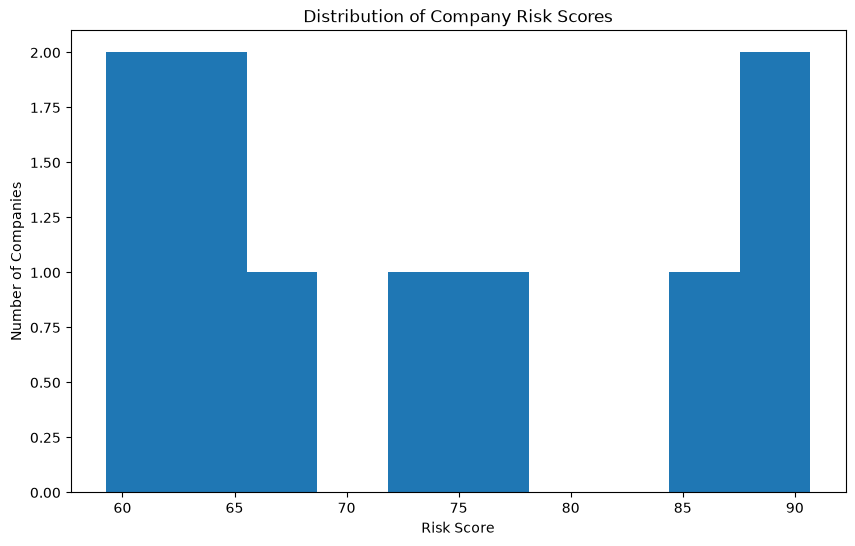

In [249]:
plt.figure(figsize=(10, 6))

plt.hist(
    company_analysis["Risk_Score_100"],
    bins=10
)

plt.xlabel("Risk Score")
plt.ylabel("Number of Companies")
plt.title("Distribution of Company Risk Scores")

plt.show()

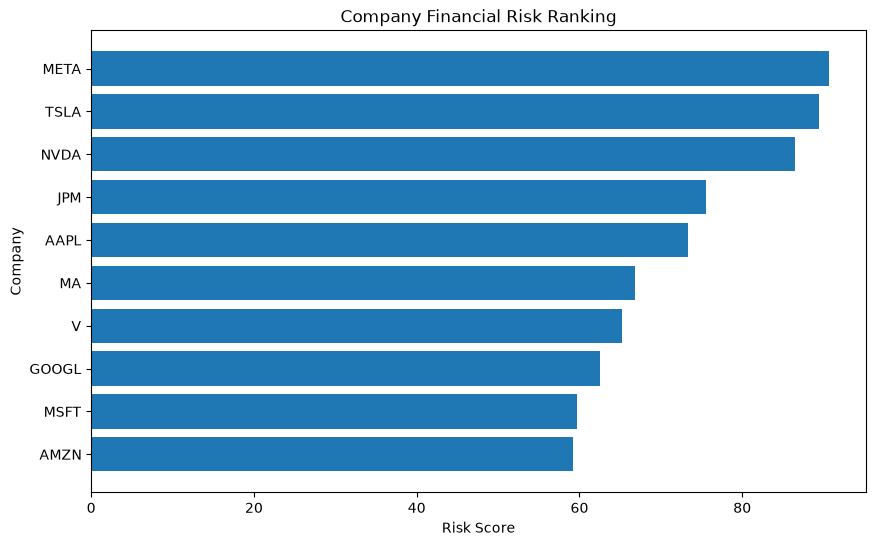

In [251]:
risk_plot = company_analysis.sort_values(
    "Risk_Score_100",
    ascending=True
)

plt.figure(figsize=(10, 6))

plt.barh(
    risk_plot["ticker"],
    risk_plot["Risk_Score_100"]
)

plt.xlabel("Risk Score")
plt.ylabel("Company")
plt.title("Company Financial Risk Ranking")

plt.show()

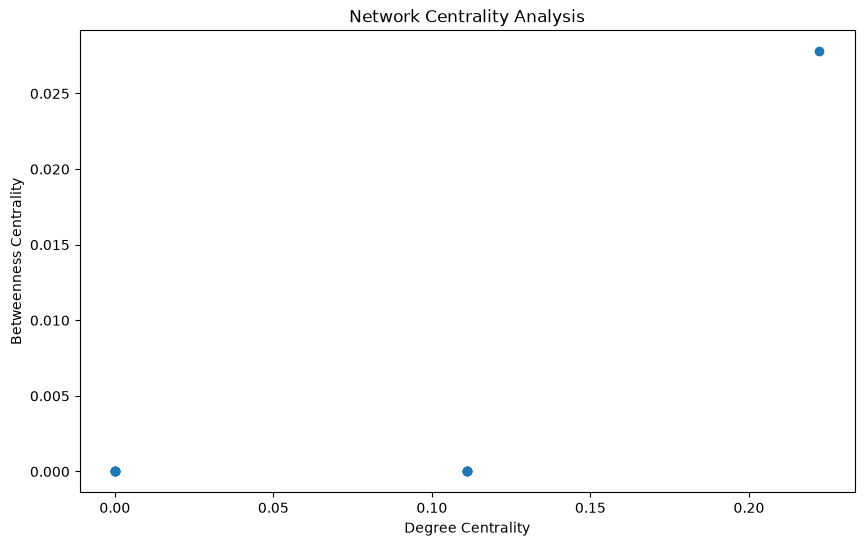

In [252]:
plt.figure(figsize=(10, 6))

plt.scatter(
    company_analysis["Degree_Centrality"],
    company_analysis["Betweenness_Centrality"]
)

plt.xlabel("Degree Centrality")
plt.ylabel("Betweenness Centrality")
plt.title("Network Centrality Analysis")

plt.show()

In [254]:
print(community_risk.columns.tolist())
print(community_risk.head())

['Community', 'Average_Volatility', 'Company_Count']
   Community  Average_Volatility  Company_Count
0          0            0.020296              3
1          1            0.014775              2
2          2            0.017664              1
3          3            0.015383              1
4          4            0.028266              1


In [255]:
community_risk = (
    company_analysis
    .groupby("Community")
    .agg(
        Average_Risk=("Risk_Score_100", "mean"),
        Company_Count=("ticker", "count")
    )
    .reset_index()
)

In [256]:
print(community_risk)

   Community  Average_Risk  Company_Count
0          0     60.492117              3
1          1     66.032746              2
2          2     73.344204              1
3          3     75.508636              1
4          4     90.694436              1
5          5     86.534037              1
6          6     89.452887              1


In [257]:
community_plot = community_risk.sort_values(
    "Average_Risk"
)

In [258]:
community_risk = (
    company_analysis
    .groupby("Community")
    .agg(
        Average_Risk=("Risk_Score_100", "mean"),
        Company_Count=("ticker", "count")
    )
    .reset_index()
)

community_plot = community_risk.sort_values(
    "Average_Risk",
    ascending=False
)

print(community_plot)

   Community  Average_Risk  Company_Count
4          4     90.694436              1
6          6     89.452887              1
5          5     86.534037              1
3          3     75.508636              1
2          2     73.344204              1
1          1     66.032746              2
0          0     60.492117              3


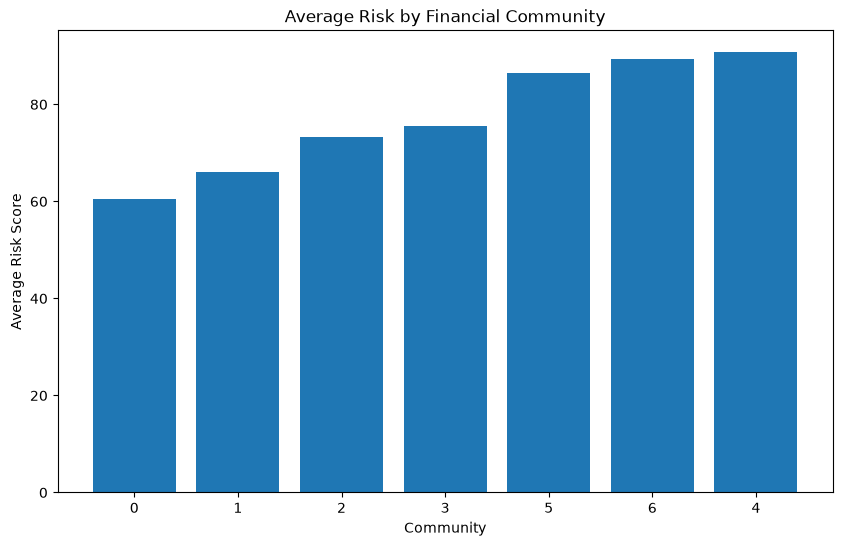

In [259]:
community_plot = community_risk.sort_values(
    "Average_Risk"
)

plt.figure(figsize=(10, 6))

plt.bar(
    community_plot["Community"].astype(str),
    community_plot["Average_Risk"]
)

plt.xlabel("Community")
plt.ylabel("Average Risk Score")
plt.title("Average Risk by Financial Community")

plt.show()

In [260]:
output_dir = Path("../data/outputs")

output_dir.mkdir(
    parents=True,
    exist_ok=True
)

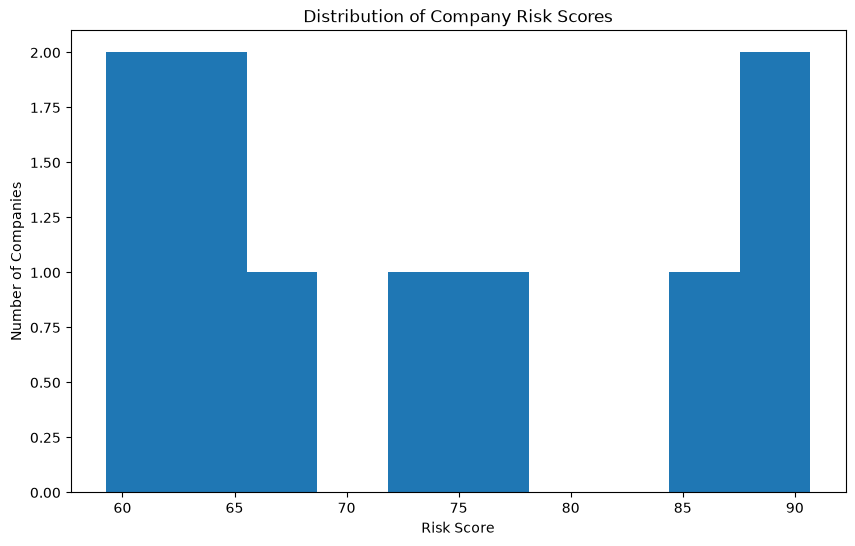

In [261]:
plt.figure(figsize=(10, 6))

plt.hist(
    company_analysis["Risk_Score_100"],
    bins=10
)

plt.xlabel("Risk Score")
plt.ylabel("Number of Companies")
plt.title("Distribution of Company Risk Scores")

plt.savefig(
    output_dir / "risk_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

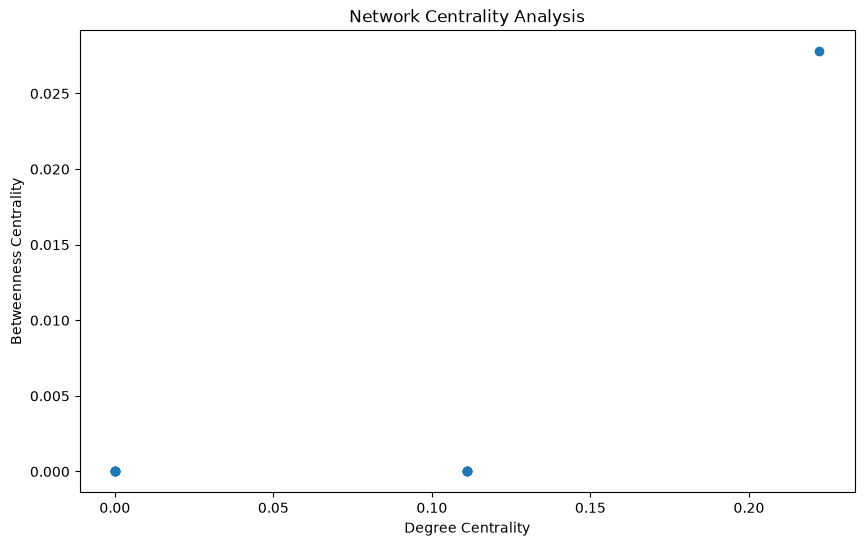

In [262]:
plt.figure(figsize=(10, 6))

plt.scatter(
    company_analysis["Degree_Centrality"],
    company_analysis["Betweenness_Centrality"]
)

plt.xlabel("Degree Centrality")
plt.ylabel("Betweenness Centrality")
plt.title("Network Centrality Analysis")

plt.savefig(
    output_dir / "centrality_analysis.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

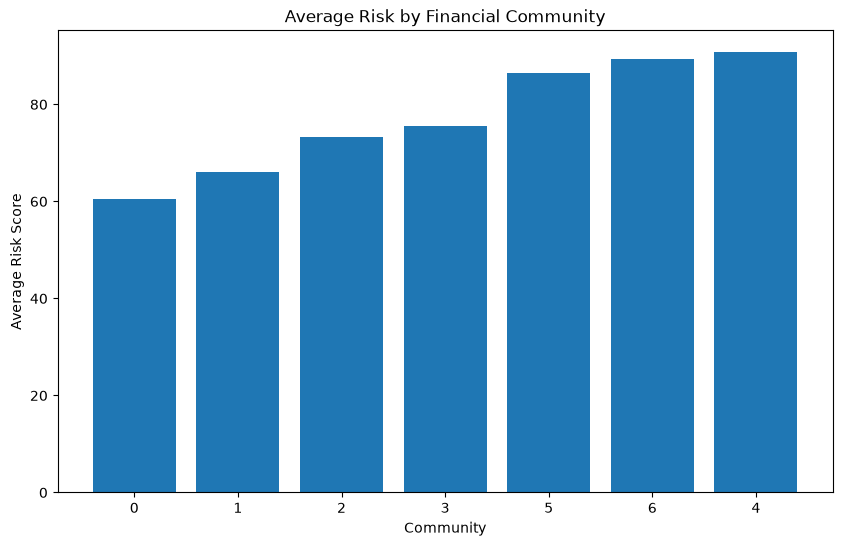

In [263]:
plt.figure(figsize=(10, 6))

plt.bar(
    community_plot["Community"].astype(str),
    community_plot["Average_Risk"]
)

plt.xlabel("Community")
plt.ylabel("Average Risk Score")
plt.title("Average Risk by Financial Community")

plt.savefig(
    output_dir / "community_analysis.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [265]:
final_intelligence = company_analysis[
    [
        "ticker",
        "Community",
        "Degree",
        "Betweenness_Centrality",
        "Volatility",
        "Max_Drawdown",
        "Risk_Score_100",
        "Risk_Category",
        "Risk_Rank"
    ]
].sort_values(
    "Risk_Rank"
)

In [266]:
final_intelligence

,ticker,Community,Degree,Betweenness_Centrality,Volatility,Max_Drawdown,Risk_Score_100,Risk_Category,Risk_Rank
8,META,4,0,0.000000,0.028266,-0.767361,90.694436,Critical,1
9,TSLA,6,0,0.000000,0.037575,-0.736322,89.452887,Critical,2
0,NVDA,5,0,0.000000,0.032695,-0.663351,86.534037,Critical,3
2,JPM,3,0,0.000000,0.015383,-0.387716,75.508636,High,4
4,AAPL,2,0,0.000000,0.017664,-0.333605,73.344204,High,5
5,MA,1,1,0.000000,0.015108,-0.282503,66.855239,High,6
6,V,1,1,0.000000,0.014442,-0.241379,65.210254,High,7
1,GOOGL,0,1,0.000000,0.020229,-0.443201,62.542836,High,8
7,MSFT,0,1,0.000000,0.017737,-0.371485,59.674209,Medium,9
3,AMZN,0,2,0.027778,0.022923,-0.557258,59.259306,Medium,10


In [267]:
top_5_risky = final_intelligence.head(5)

top_5_risky

,ticker,Community,Degree,Betweenness_Centrality,Volatility,Max_Drawdown,Risk_Score_100,Risk_Category,Risk_Rank
8,META,4,0,0.0,0.028266,-0.767361,90.694436,Critical,1
9,TSLA,6,0,0.0,0.037575,-0.736322,89.452887,Critical,2
0,NVDA,5,0,0.0,0.032695,-0.663351,86.534037,Critical,3
2,JPM,3,0,0.0,0.015383,-0.387716,75.508636,High,4
4,AAPL,2,0,0.0,0.017664,-0.333605,73.344204,High,5


In [269]:
top_5_influential = (
    company_analysis
    .sort_values(
        "Degree_Centrality",
        ascending=False
    )
    [
        [
            "ticker",
            "Degree_Centrality",
            "Betweenness_Centrality",
            "Community"
        ]
    ]
    .head(5)
)

top_5_influential

,ticker,Degree_Centrality,Betweenness_Centrality,Community
3,AMZN,0.222222,0.027778,0
1,GOOGL,0.111111,0.000000,0
7,MSFT,0.111111,0.000000,0
5,MA,0.111111,0.000000,1
6,V,0.111111,0.000000,1


In [270]:
top_5_bridges = (
    company_analysis
    .sort_values(
        "Betweenness_Centrality",
        ascending=False
    )
    [
        [
            "ticker",
            "Betweenness_Centrality",
            "Community",
            "Risk_Score_100"
        ]
    ]
    .head(5)
)

top_5_bridges

,ticker,Betweenness_Centrality,Community,Risk_Score_100
3,AMZN,0.027778,0,59.259306
0,NVDA,0.000000,5,86.534037
1,GOOGL,0.000000,0,62.542836
2,JPM,0.000000,3,75.508636
4,AAPL,0.000000,2,73.344204


In [271]:
print("Company risk dataset:")
print(company_risk_scores.shape)

print("\nCommunity analysis:")
print(community_risk.shape)

print("\nRisk categories:")
print(
    company_analysis["Risk_Category"]
    .value_counts()
)

print("\nTop risky companies:")
print(
    company_risk_scores.head()
)

Company risk dataset:
(10, 14)

Community analysis:
(7, 3)

Risk categories:
Risk_Category
High        5
Critical    3
Medium      2
Name: count, dtype: int64

Top risky companies:
  ticker  Degree  Weighted_Degree  Degree_Centrality  Betweenness_Centrality  \
8   META       0              0.0                0.0                     0.0   
9   TSLA       0              0.0                0.0                     0.0   
0   NVDA       0              0.0                0.0                     0.0   
2    JPM       0              0.0                0.0                     0.0   
4   AAPL       0              0.0                0.0                     0.0   

   Closeness_Centrality  Eigenvector_Centrality  Community  Volatility  \
8                   0.0            1.252715e-21          4    0.028266   
9                   0.0            1.252715e-21          6    0.037575   
0                   0.0            1.252715e-21          5    0.032695   
2                   0.0            1.25271

In [272]:
for file in processed_path.iterdir():
    print(file.name)

community_analysis.csv
company_risk_scores.csv
correlation_matrix.csv
financial_graph.gml
graph_metrics.csv
stock_prices_clean.csv


In [273]:
for file in output_dir.iterdir():
    print(file.name)

centrality_analysis.png
community_analysis.png
risk_distribution.png
